# Integrated Illness Prediction - Electronic Medical Certificate (IIP-EMC) Engine
## Part 1: Leakage-Safe Data Preparation

### Objective
- **What is implemented:** a reproducible preprocessing workflow for the symptom-classification dataset used by the IIP-EMC prototype.
- **How it is implemented:** the notebook cleans and validates source files, removes duplicates, audits class support, and creates a fixed train/test split.
- **Why it is implemented this way:** learned operations are deferred to `ML-Training.ipynb` so they cannot leak information from validation or test data.

### Clinical and Dataset Boundary
- **What is implemented:** an explicit limitation statement for downstream components.
- **How it is implemented:** the original symptom dataset is retained and no synthetic patient demographics or findings are added.
- **Why it is implemented this way:** the dataset is educational rather than clinically validated, so outputs support clinician review only and a clinician remains responsible for EMC issuance.

### Data Contract
- **What is implemented:** validation for `train_disease.csv` and `test_disease.csv`, plus the reusable artifact `iip_emc_preprocessed_data.pkl`.
- **How it is implemented:** the artifact stores deduplicated partitions, ordered binary symptom schema, label metadata, and preprocessing audit information.
- **Why duplicates are removed:** repeated records inflate performance without adding independent evidence.
- **Why original labels are retained:** unrelated illnesses are not merged into broad categories that hide source-data meaning.
- **Why scaling is omitted:** all retained symptoms are binary `0/1` flags.
- **Why over-sampling is omitted:** balancing must occur inside the later cross-validation pipeline to prevent leakage.

### Step 1: Imports and Reproducibility Settings
- **What is implemented:** library imports, fixed constants, artifact paths, and warning suppression.
- **How it is implemented:** random seed, test size, class-support threshold, column names, and output locations are declared once.
- **Why it is implemented this way:** centralised settings make reruns reproducible and prevent warning output from obscuring audit results.

### Implementation Overview
- **What is implemented:** a strict handoff boundary between data preparation and ML training.
- **How it is implemented:** this notebook saves raw binary partitions and metadata; `ML-Training.ipynb` receives the schema and performs learned transformations.
- **Why it is implemented this way:** separating responsibilities makes leakage controls auditable and preserves the final test partition.
- **Produced artifact:** `iip_emc_preprocessed_data.pkl` contains feature schema, train/test data, label metadata, and audit results.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from datetime import datetime, timezone

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.20
MIN_CLASS_SAMPLES = 5
PREPROCESSING_VERSION = "v4.0-leakage-safe"
RAW_TARGET_COLUMN = "prognosis"
TARGET_COLUMN = "Target_Illness"

TRAIN_PATH = Path("train_disease.csv")
TEST_PATH = Path("test_disease.csv")
OUTPUT_PATH = Path("iip_emc_preprocessed_data.pkl")

pd.set_option("display.max_rows", 100)
print(f"Preprocessing version: {PREPROCESSING_VERSION}")

Preprocessing version: v4.0-leakage-safe


### Step 2: Load and Validate the Raw Files
- **What is implemented:** CSV loading, export-index removal, schema comparison, and target-column validation.
- **How it is implemented:** source files are aligned to one column order and combined before any cleaning decision.
- **Why it is implemented this way:** the supplied split contains repeated records, so recombination allows duplicates to be removed before creating a defensible stratified split.

In [2]:
def drop_export_artifact_columns(frame: pd.DataFrame) -> pd.DataFrame:
    """Remove CSV index-export columns without silently discarding clinical features."""
    artifact_columns = [
        column for column in frame.columns
        if column.strip().lower().startswith("unnamed:")
    ]
    return frame.drop(columns=artifact_columns, errors="ignore")


def normalize_label(value: object) -> str:
    """Normalise whitespace only; do not create undocumented clinical label groupings."""
    return " ".join(str(value).split())


if not TRAIN_PATH.exists() or not TEST_PATH.exists():
    raise FileNotFoundError("Expected train_disease.csv and test_disease.csv in the notebook folder.")

raw_train = drop_export_artifact_columns(pd.read_csv(TRAIN_PATH))
raw_test = drop_export_artifact_columns(pd.read_csv(TEST_PATH))

if set(raw_train.columns) != set(raw_test.columns):
    raise ValueError("Raw train/test schemas differ after removing export-artifact columns.")

raw_test = raw_test[raw_train.columns]
raw_data = pd.concat([raw_train, raw_test], ignore_index=True)

if RAW_TARGET_COLUMN not in raw_data.columns:
    raise KeyError(f"Expected target column '{RAW_TARGET_COLUMN}' was not found.")

raw_feature_columns = [column for column in raw_data.columns if column != RAW_TARGET_COLUMN]

print(f"Raw train rows: {len(raw_train):,}")
print(f"Raw test rows:  {len(raw_test):,}")
print(f"Combined rows:  {len(raw_data):,}")
print(f"Raw symptom columns: {len(raw_feature_columns)}")

Raw train rows: 4,920
Raw test rows:  42
Combined rows:  4,962
Raw symptom columns: 132


### Step 3: Data Quality Audit and Duplicate Policy
- **What is implemented:** checks for missing values, exact duplicates, unique symptom fingerprints, and conflicting labels.
- **How it is implemented:** symptom columns form a fingerprint; duplicate rows are removed and fingerprints linked to multiple diagnoses are counted.
- **Why it is implemented this way:** duplicate records are not independent evidence, while conflicting labels expose ambiguity a symptom-only classifier cannot reliably resolve.

In [3]:
data = raw_data.copy()
data[RAW_TARGET_COLUMN] = data[RAW_TARGET_COLUMN].map(normalize_label)

# Symptoms must be binary for the downstream binary-feature contract.
for column in raw_feature_columns:
    data[column] = pd.to_numeric(data[column], errors="raise")

non_binary_columns = [
    column for column in raw_feature_columns
    if not data[column].isin([0, 1]).all()
]
if non_binary_columns:
    raise ValueError(f"Expected binary symptom flags; non-binary columns: {non_binary_columns}")

if data[RAW_TARGET_COLUMN].isna().any() or (data[RAW_TARGET_COLUMN] == "").any():
    raise ValueError("Target labels must be present and non-empty.")

exact_duplicate_count = int(data.duplicated().sum())
data = data.drop_duplicates().reset_index(drop=True)

fingerprint = data[raw_feature_columns].apply(tuple, axis=1)
fingerprint_label_counts = data.assign(_fingerprint=fingerprint).groupby("_fingerprint")[RAW_TARGET_COLUMN].nunique()
ambiguous_fingerprints = fingerprint_label_counts[fingerprint_label_counts > 1]

print(f"Exact duplicates removed: {exact_duplicate_count:,}")
print(f"Unique records retained:  {len(data):,}")
print(f"Missing values:           {int(data.isna().sum().sum()):,}")
print(f"Unique fingerprints:      {len(fingerprint_label_counts):,}")
print(f"Ambiguous fingerprints:   {len(ambiguous_fingerprints):,}")

if len(ambiguous_fingerprints):
    print("WARNING: identical symptom patterns have conflicting labels. This limits symptom-only prediction.")
else:
    print("No conflicting labels were found for identical symptom fingerprints.")

Exact duplicates removed: 4,657
Unique records retained:  305
Missing values:           0
Unique fingerprints:      305
Ambiguous fingerprints:   0
No conflicting labels were found for identical symptom fingerprints.


### Step 4: Target Scope and Class-Support Audit
- **What is implemented:** normalisation of label whitespace, class-frequency reporting, and a minimum-support check.
- **How it is implemented:** diagnosis labels remain separate and the smallest class count is used to calculate the maximum valid stratified cross-validation folds.
- **Why it is implemented this way:** preserving labels avoids undocumented clinical grouping, while explicit class support prevents a cross-validation split that would omit a class from a training fold.

In [4]:
data[TARGET_COLUMN] = data[RAW_TARGET_COLUMN]
class_counts = data[TARGET_COLUMN].value_counts().sort_values(ascending=True)
insufficient_labels = class_counts[class_counts < MIN_CLASS_SAMPLES]

print(f"Target classes retained: {class_counts.size}")
print(f"Class support range: {class_counts.min()} to {class_counts.max()} unique records")
print(f"Classes below the minimum support policy ({MIN_CLASS_SAMPLES}): {len(insufficient_labels)}")

if len(insufficient_labels):
    raise ValueError(
        "Some target classes have insufficient support for the declared policy: "
        f"{insufficient_labels.to_dict()}"
    )

class_support_table = class_counts.rename_axis("target_label").reset_index(name="unique_record_count")
class_support_table

Target classes retained: 41
Class support range: 5 to 10 unique records
Classes below the minimum support policy (5): 0


,target_label,unique_record_count
0,Urinary tract infection,5
1,Heart attack,5
2,Allergy,5
3,Acne,5
4,Gastroenteritis,5
5,AIDS,5
6,Paralysis (brain hemorrhage),5
7,Impetigo,6
8,Drug Reaction,6
9,Hypertension,6


### Step 5: Hold-Out Split Before Any Learned Transformation
- **What is implemented:** one reproducible stratified train/test split and a post-split fingerprint-overlap audit.
- **How it is implemented:** `train_test_split` uses the fixed random state and diagnosis labels; partitions are checked for overlapping fingerprints.
- **Why feature selection is excluded:** a selector must learn from each training fold only in the ML pipeline, never from hold-out data.
- **Why overlap is reported:** non-independent train/test patterns are visible instead of silently producing optimistic evaluation.

In [5]:
x = data[raw_feature_columns].copy()
y = data[TARGET_COLUMN].copy()

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

train_fingerprints = set(x_train.apply(tuple, axis=1))
test_fingerprints = x_test.apply(tuple, axis=1)
test_fingerprint_overlap = float(test_fingerprints.isin(train_fingerprints).mean())
min_train_class_support = int(y_train.value_counts().min())
recommended_cv_folds = min(3, min_train_class_support)

if recommended_cv_folds < 2:
    raise ValueError("Not enough per-class training support for cross-validation after the hold-out split.")

print(f"Training rows: {len(x_train):,}")
print(f"Test rows:     {len(x_test):,}")
print(f"Minimum class support in training: {min_train_class_support}")
print(f"Recommended CV folds for ML notebook: {recommended_cv_folds}")
print(f"Test rows with a training fingerprint match: {test_fingerprint_overlap:.1%}")

if test_fingerprint_overlap > 0:
    print("WARNING: overlapping fingerprints require a group-aware split discussion in the model report.")
else:
    print("No symptom-fingerprint overlap between the hold-out partitions.")

Training rows: 244
Test rows:     61
Minimum class support in training: 4
Recommended CV folds for ML notebook: 3
Test rows with a training fingerprint match: 0.0%
No symptom-fingerprint overlap between the hold-out partitions.


### Step 6: Exploratory Data Analysis Visuals
- **What is implemented:** charts showing deduplicated class distribution and symptom-frequency patterns.
- **How it is implemented:** plots use cleaned records and the retained binary schema passed to model training.
- **Why it is implemented this way:** analysis reflects independent records and makes small per-class support visible as a limitation.

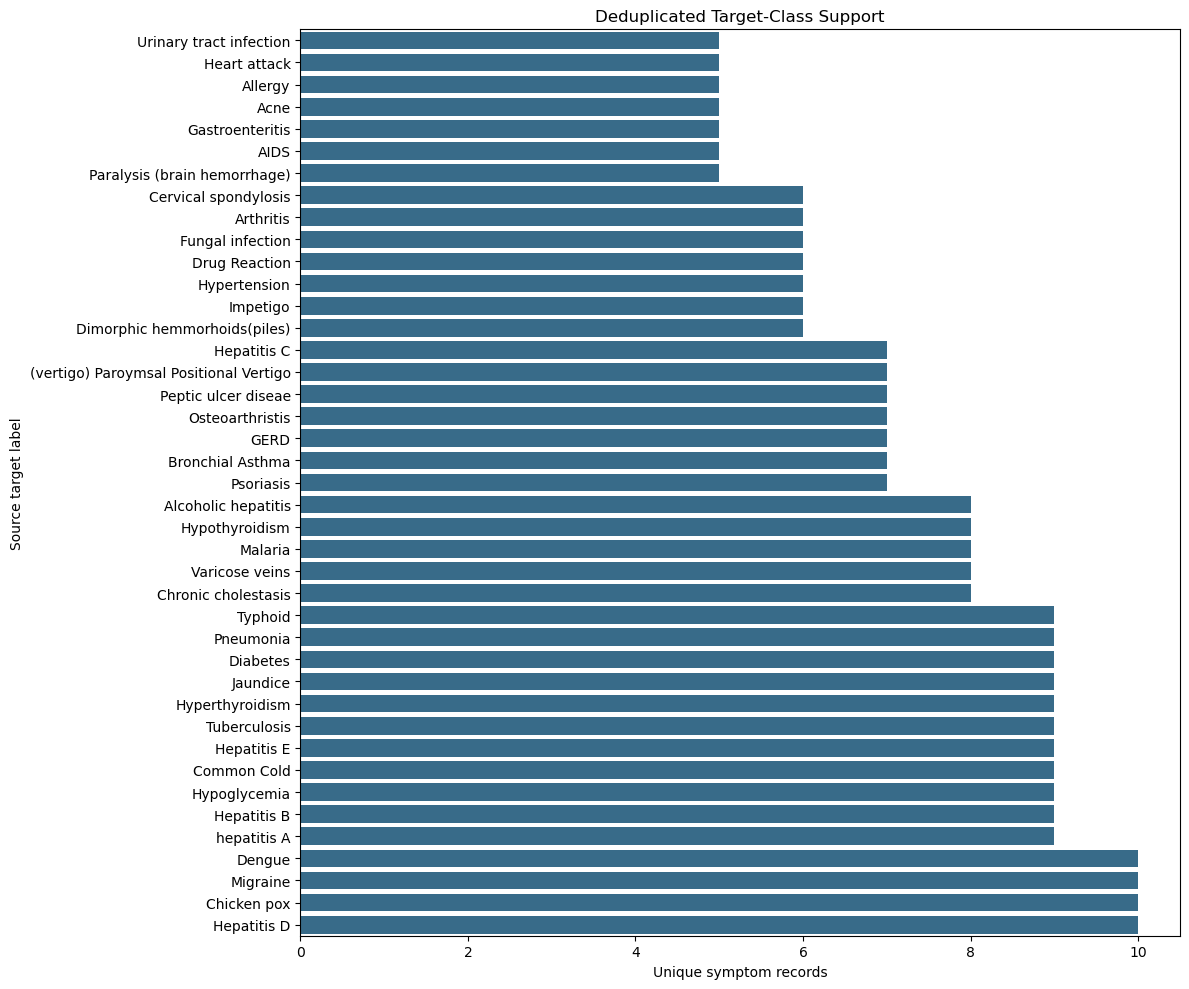

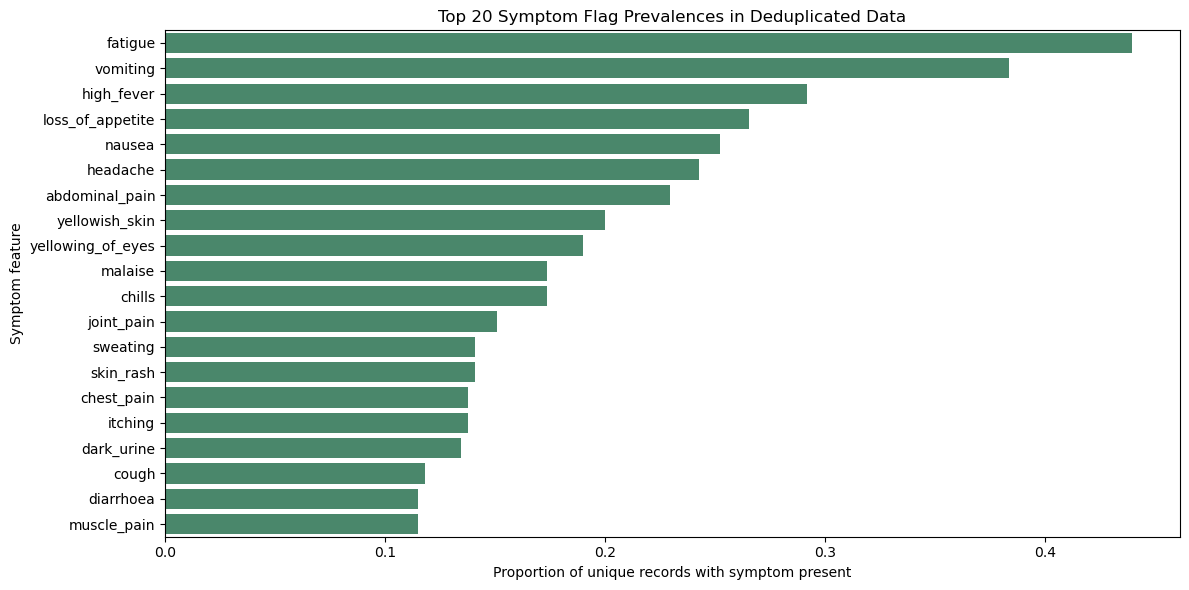

In [6]:
plt.figure(figsize=(12, 10))
sns.barplot(
    data=class_support_table.sort_values("unique_record_count", ascending=True),
    x="unique_record_count",
    y="target_label",
    color="#2a6f97",
)
plt.title("Deduplicated Target-Class Support")
plt.xlabel("Unique symptom records")
plt.ylabel("Source target label")
plt.tight_layout()
plt.show()

feature_prevalence = x.mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_prevalence.values, y=feature_prevalence.index, color="#40916c")
plt.title("Top 20 Symptom Flag Prevalences in Deduplicated Data")
plt.xlabel("Proportion of unique records with symptom present")
plt.ylabel("Symptom feature")
plt.tight_layout()
plt.show()

### Step 7: Save the Training Contract
- **What is implemented:** serialization of cleaned partitions, ordered feature names, label metadata, and audit information.
- **How it is implemented:** `joblib` writes a versioned dictionary to `iip_emc_preprocessed_data.pkl`.
- **Why no scaler or resampled matrix is saved:** binary symptoms require no scaling and learned/resampled data belongs inside ML training folds.
- **Why this contract matters:** exact feature order prevents mismatched symptom inputs during inference and in the web app.

In [7]:
preprocessing_audit = {
    "preprocessing_version": PREPROCESSING_VERSION,
    "created_at_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "raw_row_count": int(len(raw_data)),
    "deduplicated_row_count": int(len(data)),
    "exact_duplicates_removed": exact_duplicate_count,
    "raw_feature_count": int(len(raw_feature_columns)),
    "target_class_count": int(y.nunique()),
    "test_fingerprint_overlap_rate": test_fingerprint_overlap,
    "minimum_training_class_support": min_train_class_support,
    "recommended_cv_folds": recommended_cv_folds,
    "known_limitations": [
        "Educational Kaggle dataset; not validated for clinical diagnosis.",
        "Deduplicated class support is small, so per-class estimates are unstable.",
        "Feature selection and resampling are intentionally deferred to the ML training pipeline.",
    ],
}

processed_data_payload = {
    "x_train": x_train,
    "x_test": x_test,
    "y_train": y_train,
    "y_test": y_test,
    "scaler": None,
    "symptom_columns": list(raw_feature_columns),
    "feature_columns": list(raw_feature_columns),
    "target_column": TARGET_COLUMN,
    "class_support_table": class_support_table,
    "preprocessing_audit": preprocessing_audit,
}

joblib.dump(processed_data_payload, OUTPUT_PATH)

print(f"Saved leakage-safe preprocessing artifact: {OUTPUT_PATH.resolve()}")
print("Next notebook contract:")
print("- binary symptom schema only")
print("- scaler is None")
print("- use preprocessing_audit['recommended_cv_folds'] for safe cross-validation")
print("- fit feature selection and any sampler inside the ML pipeline")

Saved leakage-safe preprocessing artifact: C:\Users\jys20\miniconda3\envs\it3100\AAP\iip_emc_preprocessed_data.pkl
Next notebook contract:
- binary symptom schema only
- scaler is None
- use preprocessing_audit['recommended_cv_folds'] for safe cross-validation
- fit feature selection and any sampler inside the ML pipeline


### Summary
- **Implemented:** source validation, export-column removal, label normalisation, missing-value checks, duplicate removal, fingerprint-conflict checks, class-support audit, stratified split, EDA, and artifact serialization.
- **Implementation approach:** raw files are combined before cleaning; all partitions use one ordered binary symptom schema; the split and audit information are saved in `iip_emc_preprocessed_data.pkl`.
- **Why this approach:** removing duplicates before splitting and delaying learned transformations prevents optimistic evaluation caused by duplicates or data leakage.
- **Handoff:** `ML-Training.ipynb` consumes the saved partitions and schema without changing the test-set boundary.
- **Limitation:** this educational dataset supports clinician-reviewed decision support only; it is not a validated diagnostic dataset.